## Source Data
https://clearinghouse.isgs.illinois.edu/data/elevation/illinois-height-modernization-ilhmp

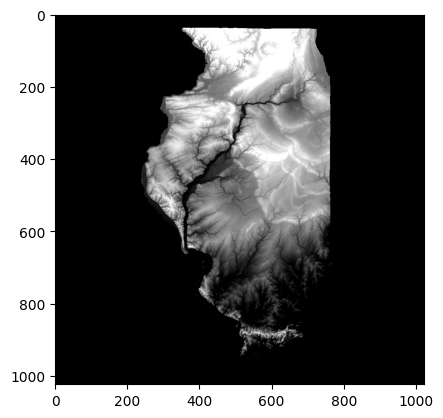

In [1]:
import matplotlib.pyplot as plt 

dem = plt.imread('IL_Statewide_Lidar_DEM_WGS.png')[:,:,0]
plt.imshow(dem, cmap='gray', vmin=0, vmax=1)

## Math Refresher

### 3D Vectors
- Dot product of unit vectors: $\vec{u}\cdot\vec{v} = u_xv_x + u_yv_y + u_zv_z = cos\theta$
- Cross product of unit vectors $\vec{u}\times\vec{v} = (u_yv_z-u_zv_y)\vec{e}_x + (u_zv_x-u_xv_z)\vec{e}_y + (u_xv_y-u_yv_x)\vec{e}_z = sin\theta\ \vec{n}$

<img src="https://upload.wikimedia.org/wikipedia/commons/d/d2/Right_hand_rule_cross_product.svg" width="400">

### Surfaces
If we have a (continuous) height $f(x,y)$ at each $(x,y)$, $f$ gives us a surface $\vec{r}(x, y) = (x, y, f(x, y))^\top$. 

<img src="https://upload.wikimedia.org/wikipedia/commons/a/ab/2D_Wavefunction_%282%2C1%29_Surface_Plot.png" width="500">

The tangent vectors are given by partial derivatives:
$$\vec{u}(x,y) = \frac{\partial \vec{r}}{\partial x}(x,y) = \left(1, 0, \frac{\partial f}{\partial x}(x, y)\right)^\top, \quad
\vec{v}(x,y) = \frac{\partial \vec{r}}{\partial y}(x,y) = \left(0, 1, \frac{\partial f}{\partial x}(x, y)\right)^\top$$
The normal vector is the cross product of the two:
$$\vec{N}(x,y) = \vec{u}(x,y)\times\vec{v}(x,y) = \left(-\frac{\partial f}{\partial x}(x, y), -\frac{\partial f}{\partial y}(x, y), 2\right)^\top, \quad \vec{n} = \frac{\vec{N}}{\Vert \vec{N} \Vert}$$

<img src="https://upload.wikimedia.org/wikipedia/commons/a/a8/Normal_vectors_on_a_curved_surface.svg" width="500">

The discretized version, which we can implement on a computer, is:
$$\vec{n}[i,j] = \left(\frac{f[i, j-1] - f[i, j+1]}{2}, \frac{f[i+1,j] - f[i-1,j]}{2}, 2\right)^\top$$

## Implementation

In [2]:
from numba import njit, prange
import numpy as np

We use two angles $\theta$ and $\psi$ to describe the light direction:
$$\vec{l}(\theta, \psi) = \left(\cos\theta\cos\psi, \cos\theta\sin\psi, \sin\theta \right)^\top$$
<img src="https://upload.wikimedia.org/wikipedia/commons/3/30/Plane_with_ENU_embedded_axes.svg" width="300">

In [3]:
@njit
def light(theta, psi):
    return np.array([
        np.cos(np.radians(theta)) * np.cos(np.radians(psi)),
        np.cos(np.radians(theta)) * np.sin(np.radians(psi)),
        np.sin(np.radians(theta))
    ])

## Computer Graphics Primer

### Phong Shading (1975)
Given surface normal (unit vector) $\vec{n}$, light direction (unit vector) $\vec{l}$, eye direction (unit vector) $\vec{v}$, the reflected light direction (unit vector) is $r = 2 (\vec{l}\cdot \vec{n})\vec{n} - \vec{l}$.

A pixel's color intensity $I$ consists of three components: ambient lighting: $k_{a}$, diffuse lighting: $k_{d}\ \vec{l} \cdot \vec{n}$, and specular lighting: $k_{s}\ (\vec{r} \cdot \vec{v})^ r$.

$$I = k_{a} + k_{d}\ \vec{l} \cdot \vec{n} + k_{s}\ (\vec{r} \cdot \vec{v})^r$$

<img src="https://upload.wikimedia.org/wikipedia/commons/6/6b/Phong_components_version_4.png">

In [4]:
@njit
def accumulate(normal, eye_dir, light_dir, light_color, k_d, k_s):   
    """
    This function will be stubbed out
    """
    d = max(0., light_dir.dot(normal))
    diffuse = k_d * d * light_color

    reflection_dir = normal * 2 * d - light_dir
    specular = k_s * reflection_dir.dot(eye_dir) ** 3 * light_color
    
    return diffuse + specular

In [5]:
@njit
def shade_pixel(out, dem, i, j, exaggeration, theta, psi, k_a, k_d, k_s):
    ambient = k_a * np.array([1,1,1])
    pixel = ambient

    v = np.array([0.0, 0.0, 1.0])

    n = np.array([
        exaggeration * (dem[i][j - 1] - dem[i][j + 1]), # -df/dx
        exaggeration * (dem[i + 1][j] - dem[i - 1][j]), # -df/dy
        4
    ])
    n /= np.linalg.norm(n)

    # Experiment with this
    lights = [
        (light(theta, psi), np.array([1, 0.5, 0])),
        (light(theta + 10, psi + 100), np.array([0, 0.5, 1]))
    ]

    for l, c in lights:
        pixel += accumulate(n, v, l, c, k_d, k_s)

    return pixel

In [6]:
@njit(parallel=True)
def render(dem, exaggeration, theta, psi, k_a, k_d, k_s):
    H, W = dem.shape
    out = np.zeros((H, W, 3))    
    for i in prange(1, H - 1):
        for j in prange(1, W - 1):
            out[i, j] = shade_pixel(out, dem, i, j, exaggeration, theta, psi, k_a, k_d, k_s)
    return out.clip(0, 1)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Render time: 2.7893416667357087s

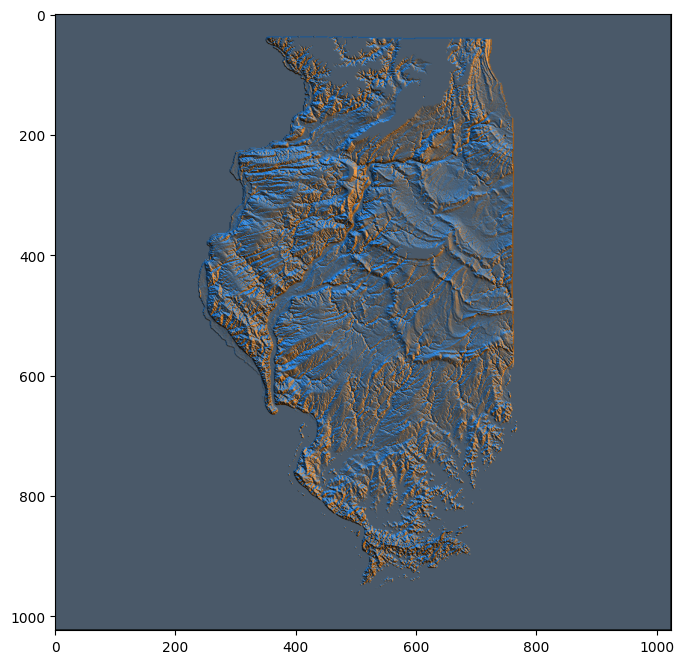

In [7]:
from timeit import default_timer as timer
from ipywidgets import interact, interactive

def draw(exaggeration=20, theta=20, psi=0, k_a=0.1, k_d=0.5, k_s=0.5):
    start = timer()
    out = render(dem, exaggeration, theta, psi, k_a, k_d, k_s)
    end = timer()
    print(f'Render time: {end - start}s', end='\r')
    plt.figure('naive', figsize=(8,8))
    plt.imshow(out)

draw()

In [8]:
widget = interactive(draw, exaggeration=(0,50), theta=(0,90), psi=(0,360), k_a=(0,1.), k_d=(0,1.), k_s=(0,1.))
widget.children[-1].layout.height = '8in'
widget

interactive(children=(IntSlider(value=20, description='exaggeration', max=50), IntSlider(value=20, description…